In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# loading json configuration file for data processing
with open('../src/config.json', 'r') as f:
    config = json.load(f)

In [3]:
# defining the source path for the dataset from the configuration file
source_path = config['data']['source']

In [4]:
# reading the games dataset
df_games = pd.read_csv(source_path)
print('Data read successfully!')

Data read successfully!


In [5]:
print(f'Dataframe shape: {df_games.shape}\n')
df_games.info()

Dataframe shape: (16715, 11)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


### dataframe first analysis
- dataframe have 16,715 records/lines;
- columns name should be updated to lowercase to avoid errors;
- NaN values should be analyzed for columns year_of_release, critic_score, user_score and rating;
- year_of_release type must be changed to int after handle NaN values;

In [6]:
# check if columns name have spaces and delete them
print(f'Column names before update:\n{df_games.columns}\n')

Column names before update:
Index(['Name', 'Platform', 'Year_of_Release', 'Genre', 'NA_sales', 'EU_sales',
       'JP_sales', 'Other_sales', 'Critic_Score', 'User_Score', 'Rating'],
      dtype='object')



In [7]:
# updating column names to snake_case
df_games.columns = df_games.columns.str.lower()
print('Column names updated to snake_case.')

Column names updated to snake_case.


In [8]:
# columns names after update
print(f'Column names after update:\n{df_games.columns}\n')

Column names after update:
Index(['name', 'platform', 'year_of_release', 'genre', 'na_sales', 'eu_sales',
       'jp_sales', 'other_sales', 'critic_score', 'user_score', 'rating'],
      dtype='object')



In [9]:
# dataframe first 5 rows
df_games.head()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN


In [10]:
# checking for full duplicates
duplicates = df_games.duplicated().sum()
print(f'Number of duplicate rows: {duplicates}')

Number of duplicate rows: 0


In [11]:
# checking for missing values
missing_values = df_games.isnull().sum()
print(f'Missing values in each column:\n{missing_values}')

Missing values in each column:
name                  2
platform              0
year_of_release     269
genre                 2
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
critic_score       8578
user_score         6701
rating             6766
dtype: int64


In [12]:
# checking if missing values in 'name' and 'genre' columns are the same
print(df_games[df_games['name'].isnull()])

      name platform  year_of_release genre  na_sales  eu_sales  jp_sales  \
659    NaN      GEN           1993.0   NaN      1.78      0.53      0.00   
14244  NaN      GEN           1993.0   NaN      0.00      0.00      0.03   

       other_sales  critic_score user_score rating  
659           0.08           NaN        NaN    NaN  
14244         0.00           NaN        NaN    NaN  


### missing values
- 'name' and 'genre' column -> drop the lines as they represent really small part of df (only 2);
- 'year_of_realese' -> check if there's any patron behind this missing values; if not fill df with median;
- 'critic_score', 'user_score' and 'rating' have several missing values; will imput values using existent data.

In [13]:
# droping rows with missing values in 'name' and 'genre' columns
df_games.dropna(subset=['name', 'genre'], inplace=True)
print('Rows with missing values in "name" and "genre" columns dropped.')

Rows with missing values in "name" and "genre" columns dropped.


#### 'year_of_release' column

In [14]:
# checking sample of missing values in 'year_of_release' column
year_null = df_games['year_of_release'].isnull()
print(df_games[year_null].sample(10))

                                                    name platform  \
15338                                       Mario Tennis      3DS   
13792                                       NHL Hitz Pro       GC   
9703                          Record of Agarest War Zero      PS3   
5624                                         Singularity     X360   
5655                              All-Star Baseball 2005      PS2   
9738   Super Robot Wars OG Saga: Masou Kishin II - Re...      PSP   
15816                                    Without Warning       XB   
2479                                       Madden NFL 07      PSP   
11338                  Charm Girls Club: My Fashion Show       DS   
9761                      Saru! Get You! Million Monkeys      PS2   

       year_of_release       genre  na_sales  eu_sales  jp_sales  other_sales  \
15338              NaN      Sports      0.00      0.00      0.02         0.00   
13792              NaN      Sports      0.03      0.01      0.00         0.00 

- no patern found in missing values at 'year_of_release' column as we cannot see a systematic behaviour like "all the NaN are from specific genre or platform";
- will check if filled cell range are acurrate and fill NaN with median.

In [15]:
# checking the distribution of 'year_of_release' column
print(df_games['year_of_release'].describe())

count    16444.000000
mean      2006.486256
std          5.875525
min       1980.000000
25%       2003.000000
50%       2007.000000
75%       2010.000000
max       2016.000000
Name: year_of_release, dtype: float64


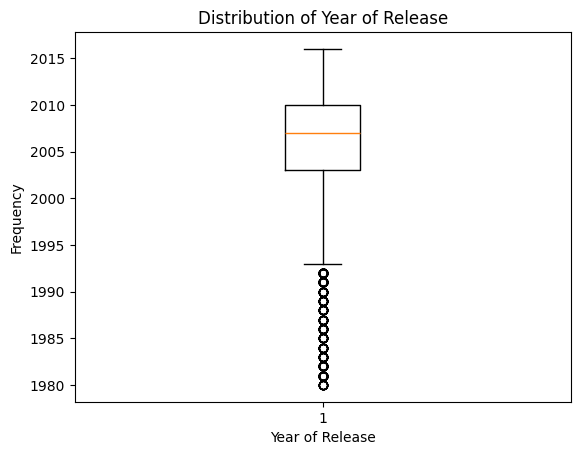

In [16]:
# boxplot of 'year_of_release' column
plt.boxplot(df_games['year_of_release'].dropna())
plt.xlabel('Year of Release')
plt.ylabel('Frequency')
plt.title('Distribution of Year of Release')
plt.show()

- Median (2007) and mean (2006.49) are close, indicating a symmetric distribution with some lower outliers (e.g., pre-1993 games). Median is robust for filling NaNs as outliers do not represent a big part of the data.

In [17]:
# getting median year of release
median_year = df_games['year_of_release'].median()
print(f"Median year of release: {median_year}")

Median year of release: 2007.0


In [18]:
# replacing missing values in 'year_of_release' column with median value
df_games['year_of_release'].fillna(median_year, inplace=True)
print('Missing values in "year_of_release" column replaced with median value (2007).')

Missing values in "year_of_release" column replaced with median value (2007).


In [19]:
# converting 'year_of_release' column to integer type
df_games['year_of_release'] = df_games['year_of_release'].astype(int)
print(f'Column "year_of_release" type: {df_games["year_of_release"].dtype}')

Column "year_of_release" type: int32


#### 'critic_score" column

In [20]:
# checking 'critic_score' column statistics
df_games['critic_score'].describe()

count    8137.000000
mean       68.967679
std        13.938165
min        13.000000
25%        60.000000
50%        71.000000
75%        79.000000
max        98.000000
Name: critic_score, dtype: float64

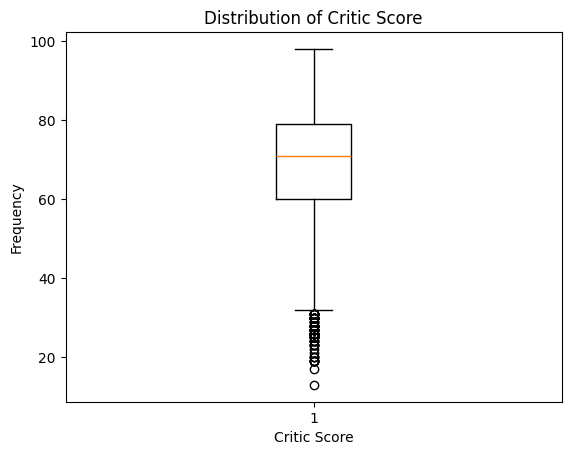

In [21]:
# boxplot of 'critc_score' column
plt.boxplot(df_games['critic_score'].dropna())
plt.xlabel('Critic Score')
plt.ylabel('Frequency')
plt.title('Distribution of Critic Score')
plt.show()

In [22]:
# checking games with 'critic_score' lower than 30 genres
print(df_games[df_games['critic_score'] < 30]['genre'].unique())

['Misc' 'Action' 'Sports' 'Racing' 'Adventure' 'Fighting' 'Shooter'
 'Puzzle' 'Platform']


In [23]:
# checking games with 'critic_score' lower than 30 year of release
print(df_games[df_games['critic_score'] < 30]['year_of_release'].unique())

[2007 2008 2010 2001 2002 2009 2000 2013 2011 2005 2012 2015 2003 2004
 2006 2014]


- from dataset documentation we know that critc_score max should be 100, so we have integrity of data;
- Median (71.00) and Mean (68.97) are close, indicating a symmetric distribution with some lower outliers. No patern found in outliers.

In [24]:
# Check sample sizes for platform-genre groups
platform_genre_sizes = df_games.groupby(['platform', 'genre']).size()
print("Group sizes summary:")
print(platform_genre_sizes.describe())
print("\nSmallest groups (potential imputation issues):")
print(platform_genre_sizes.nsmallest(10))
print("\nLargest groups:")
print(platform_genre_sizes.nlargest(10))

Group sizes summary:
count    293.000000
mean      57.040956
std       76.161947
min        1.000000
25%        7.000000
50%       24.000000
75%       74.000000
max      400.000000
dtype: float64

Smallest groups (potential imputation issues):
platform  genre     
2600      Simulation    1
3DO       Adventure     1
          Puzzle        1
          Simulation    1
DC        Simulation    1
GB        Shooter       1
GEN       Misc          1
          Racing        1
          Shooter       1
          Strategy      1
dtype: int64

Largest groups:
platform  genre     
PS2       Sports        400
DS        Misc          391
PS3       Action        380
PS2       Action        348
DS        Action        340
X360      Action        323
DS        Simulation    283
Wii       Misc          280
          Sports        260
DS        Adventure     238
dtype: int64


- as some group 'platform-genre' have small samples will will fill them using the following rules :
    1. If sample 'platform-genre' is >10 will use that group mean;
    2. Then will use only 'platform' mean also for samples bigger than 10;
    3. The remain ones will fill with dataset mean.
    * Threshold >10 chosen as 75% of groups have >10 samples, ensuring broad applicability (based on median 24 and quartile analysis), balancing coverage and reliability.

In [25]:
# Calculating samples sizes and means
# platform-genre group sizes
platform_genre_critic_size = df_games.groupby(['platform', 'genre'])[
    'critic_score'].count()
platform_genre_critic_mean = df_games.groupby(['platform', 'genre'])[
    'critic_score'].mean()

# platform group sizes and means
platform_critic_size = df_games.groupby('platform')['critic_score'].count()
platform_critic_mean = df_games.groupby('platform')['critic_score'].mean()

# overall mean
overall_critic_mean = df_games['critic_score'].mean()

In [26]:
'''function to fill missing values in a column using hierarchical imputation:
1. If the platform-genre group has more than 10 valid values, use the mean critic score of that group.
2. If the platform group has more than 10 valid values, use the mean critic score of that platform.
3. If neither condition is met, use the overall mean critic score.
This approach ensures that we use the most specific available information for imputation while maintaining reliability by requiring a minimum sample size.
'''


def fill_column_hierarchical(row, column_name=str, group_one_size=int, group_one_mean=float, group_two_size=int, group_two_mean=float, overall_mean=float):
    if pd.isna(row[column_name]):
        platform = row['platform']
        genre = row['genre']

        # checking if platform-genre group has more than 10 valid values
        if group_one_size.get((platform, genre), 0) > 10:
            return group_one_mean.get((platform, genre))

        # checking if platform group has more than 10 valid values
        elif group_two_size.get(platform, 0) > 10:
            return group_two_mean.get(platform)

        # applying overall mean if no other condition is met
        else:
            return overall_mean

    return row[column_name]

In [27]:
# filling missing values in 'critic_score' column using hierarchical imputation
df_games['critic_score'] = df_games.apply(
    lambda row: fill_column_hierarchical(
        row,
        column_name='critic_score',
        group_one_size=platform_genre_critic_size,
        group_one_mean=platform_genre_critic_mean,
        group_two_size=platform_critic_size,
        group_two_mean=platform_critic_mean,
        overall_mean=overall_critic_mean
    ), axis=1)

In [28]:
# checking if there are still missing values in 'critic_score' column
missing_critic_scores = df_games['critic_score'].isnull().sum()
print(f"Number of missing critic scores: {missing_critic_scores}")

Number of missing critic scores: 0


#### 'user_score' column

In [29]:
# checking 'user_score' column statistics
print(df_games['user_score'].value_counts().head(10))

user_score
tbd    2424
7.8     324
8       290
8.2     282
8.3     254
8.5     253
7.5     251
7.9     249
8.1     244
7.7     240
Name: count, dtype: int64


In [30]:
# checking sample of missing values in 'user_score' column
print(df_games[df_games['user_score'] == 'tbd'].sample(10))

                                        name platform  year_of_release  \
12566                            Worms Blast       GC             2002   
2675                     Tetris Party Deluxe       DS             2010   
6247                   Cabela's Trophy Bucks      PS2             2007   
6365   Final Fantasy XI: Ultimate Collection     X360             2009   
12982                            King Arthur       XB             2004   
12689                        Myst III: Exile       XB             2002   
10917         Ford Mustang: The Legend Lives       XB             2005   
3048                              Lalaloopsy       DS             2011   
4460       SpongeBob's Atlantis SquarePantis      PS2             2007   
16562          Outdoors Unleashed: Alaska 3D      3DS             2011   

              genre  na_sales  eu_sales  jp_sales  other_sales  critic_score  \
12566        Puzzle      0.05      0.01      0.00         0.00     65.000000   
2675         Puzzle      

- 'tbd' represents a considerable amount of lines (2,424) and no pattern was found like 'new game' or 'specific platform';
- will replace all the 'tbd' values to NaN and after will fill missing values with hierarchical order.

In [31]:
# replacing 'tbd' values in 'user_score' column with null
df_games['user_score'] = df_games['user_score'].replace('tbd', pd.NA)

In [32]:
# converting 'user_score' column to numeric type, coercing errors to NaN
df_games['user_score'] = pd.to_numeric(df_games['user_score'], errors='coerce')

In [33]:
# missing values in 'user_score' column after replacing 'tbd' with null
missing_user_scores = df_games['user_score'].isnull().sum()
print(
    f"Number of missing user scores after replacing 'tbd': {missing_user_scores}")

Number of missing user scores after replacing 'tbd': 9123


In [34]:
# Calculating samples sizes and means for 'user_score' column
# platform-genre group sizes
platform_genre_user_size = df_games.groupby(['platform', 'genre'])[
    'user_score'].count()
platform_genre_user_mean = df_games.groupby(
    ['platform', 'genre'])['user_score'].mean()

# platform group sizes and means
platform_user_size = df_games.groupby('platform')['user_score'].count()
platform_user_mean = df_games.groupby('platform')['user_score'].mean()

# overall mean
overall_user_mean = df_games['user_score'].mean()

In [35]:
# repolacing NaN values in 'user_score' column with mean value of full dataset for no samples 'platform-genre' groups
df_games['user_score'] = df_games.apply(
    lambda row: fill_column_hierarchical(
        row,
        column_name='user_score',
        group_one_size=platform_genre_user_size,
        group_one_mean=platform_genre_user_mean,
        group_two_size=platform_user_size,
        group_two_mean=platform_user_mean,
        overall_mean=overall_user_mean
    ), axis=1)

In [36]:
# checking if there are still missing values in 'user_score' column
missing_user_scores = df_games['user_score'].isnull().sum()
print(f"Number of missing user scores: {missing_user_scores}")

Number of missing user scores: 0


#### 'rating' column

In [37]:
# checking the distribution of 'rating' column
print(df_games['rating'].value_counts())

rating
E       3990
T       2961
M       1563
E10+    1420
EC         8
K-A        3
RP         3
AO         1
Name: count, dtype: int64


In [38]:
# checking missing values in 'rating' column
missing_rating = df_games['rating'].isnull().sum()
print(f'Missing values in "rating" column: {missing_rating}')

Missing values in "rating" column: 6764


In [39]:
# checking sample of missing values in 'rating' column
print(df_games[df_games['rating'].isnull()].sample(10))

                                                    name platform  \
8629                         Saturday Night Slam Masters     SNES   
16101                                     Kimi no Yuusha       DS   
13364  Adventure Time: Explore the Dungeon Because I ...      PS3   
15321                                           Ryu-koku      PS2   
6283                                             Gunship       PS   
10169                                      Maximum Force       PS   
9702                              Wild ARMs 5 (jp sales)      PS2   
4679                                  Mobile Suit Gundam      SAT   
7438              Tales of Phantasia: Narikiri Dungeon X      PSP   
14193  Gekiatsu!! Pachi Game Tamashi Max: Evangelion ...      PS3   

       year_of_release         genre  na_sales  eu_sales  jp_sales  \
8629              1994      Fighting      0.00      0.00      0.16   
16101             2008  Role-Playing      0.00      0.00      0.01   
13364             2013        

- 6,746 dataset lines have missing values, and as this is a important column for segmentation a 'NR' (not rated) rating will be aplied.

In [40]:
# replacing missing values in 'rating' column with 'Not_Rated'
df_games['rating'] = df_games['rating'].fillna('NR')

In [41]:
# chcking dataframe info after handle missing values and data types
df_games.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16713 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  object 
 1   platform         16713 non-null  object 
 2   year_of_release  16713 non-null  int32  
 3   genre            16713 non-null  object 
 4   na_sales         16713 non-null  float64
 5   eu_sales         16713 non-null  float64
 6   jp_sales         16713 non-null  float64
 7   other_sales      16713 non-null  float64
 8   critic_score     16713 non-null  float64
 9   user_score       16713 non-null  float64
 10  rating           16713 non-null  object 
dtypes: float64(6), int32(1), object(4)
memory usage: 1.5+ MB


In [42]:
# adding 'total_sales' column as sum of 'na_sales', 'eu_sales', 'jp_sales', and 'other_sales' columns
df_games['total_sales'] = df_games['na_sales'] + \
    df_games['eu_sales'] + df_games['jp_sales'] + df_games['other_sales']
print('Column "total_sales" added as sum of "na_sales", "eu_sales", "jp_sales", and "other_sales" columns.')

Column "total_sales" added as sum of "na_sales", "eu_sales", "jp_sales", and "other_sales" columns.


In [43]:
# print first 5 rows of the dataframe after all transformations
print(df_games.head())

                       name platform  year_of_release         genre  na_sales  \
0                Wii Sports      Wii             2006        Sports     41.36   
1         Super Mario Bros.      NES             1985      Platform     29.08   
2            Mario Kart Wii      Wii             2008        Racing     15.68   
3         Wii Sports Resort      Wii             2009        Sports     15.61   
4  Pokemon Red/Pokemon Blue       GB             1996  Role-Playing     11.27   

   eu_sales  jp_sales  other_sales  critic_score  user_score rating  \
0     28.96      3.77         8.45     76.000000    8.000000      E   
1      3.58      6.81         0.77     68.967679    7.125046     NR   
2     12.76      3.79         3.29     82.000000    8.300000      E   
3     10.93      3.28         2.95     80.000000    8.000000      E   
4      8.89     10.22         1.00     68.967679    7.125046     NR   

   total_sales  
0        82.54  
1        40.24  
2        35.52  
3        32.77  
4

In [46]:
# defining the path for the cleaned dataset from the configuration file
cleaned_path = config['data']['cleaned_data']

In [47]:
# saving the cleaned dataframe to a new CSV file
df_games.to_csv(cleaned_path, index=False)
print(f'Cleaned dataframe saved to {cleaned_path}.')

Cleaned dataframe saved to ../data/processed/cleaned_games.csv.
